# Lesson 4



This is an interactive notebook on Unsupervised Learning. 

Unsupervised Learning: We will cover Principal component analysis (PCA), KMeans clustering, and Hierchical Clustering.

I have included bonus materials on Decision Trees (supervised learning) after the unsupervised learning.

You need to install `Numpy`, `Pandas`, `seaborn`, and `scikit-learn` packages in order to run the notebook


---

All course materials, including all lecture notes and python notebooks, are for your own educational purposes only. All the contents of the materials are protected by copyright, trademark or other forms of proprietary rights.
All rights, title and interest in the materials are owned by, licensed to or controlled by the University (i.e., Nanyang Technological University), unless otherwise expressly stated. The materials shall not be uploaded, reproduced, distributed, republished or transmitted in any form or by any means, in whole or in part, without written approval from the University.

---

# Unsupervised Learning

The goal of unsupervised learning is to find hidden patterns in unlabeled data $\{\mathbf{x}^1, \dots, \mathbf{x}^m\}$. 

- Clustering: learn meaningful groupings of the data, e.g. k-means, Expectation Maximization, etc.
- Dimension reduction: learn compression of data for downstream tasks, e.g. PCA, LDA, auto-encoding, etc.
- Correlation: learn meaningful relationships between variables or units, e.g. concordance, Pearson's, etc.



https://en.wikipedia.org/wiki/Unsupervised_learning

https://scikit-learn.org/stable/unsupervised_learning.html

---
All course materials, including all lecture notes and python notebooks, are for your own educational purposes only. All the contents of the materials are protected by copyright, trademark or other forms of proprietary rights.
All rights, title and interest in the materials are owned by, licensed to or controlled by the University (i.e., Nanyang Technological University), unless otherwise expressly stated. The materials shall not be uploaded, reproduced, distributed, republished or transmitted in any form or by any means, in whole or in part, without written approval from the University.

---



## Principal component analysis (PCA)

PCA is used to decompose a multivariate dataset in a set of successive orthogonal components that explain a maximum amount of the variance. In scikit-learn, PCA is implemented as a transformer object that learns $n$ components in its `fit` method, and can be used on new data to project it on these components.

PCA centers but does not scale the input data for each feature before applying the SVD. The optional parameter whiten=True makes it possible to project the data onto the singular space while scaling each component to unit variance. This is often useful if the models down-stream make strong assumptions on the isotropy of the signal.

https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA

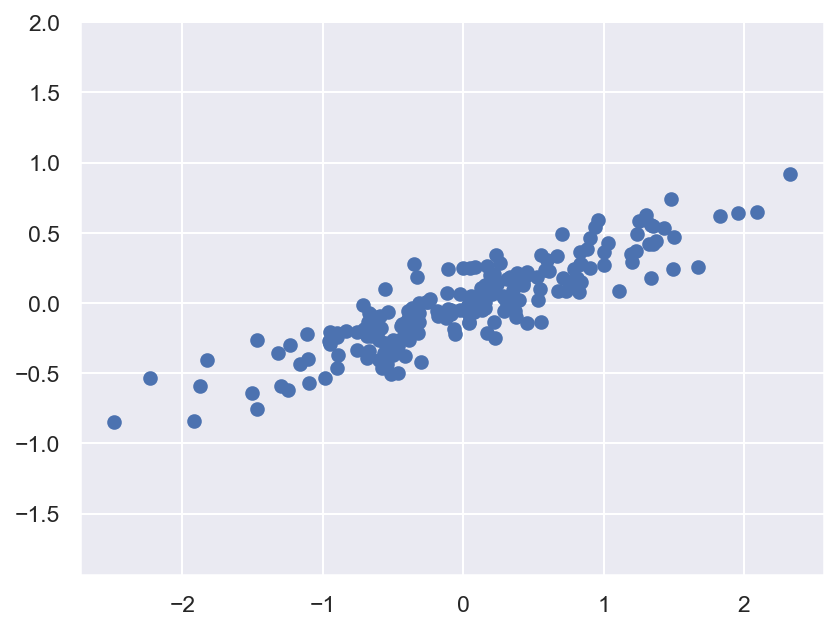

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
plt.rcParams['figure.dpi'] = 150 # change resolution

import seaborn as sns; sns.set()

rng = np.random.RandomState(1)

#two-dimensional dataset
X = np.dot(rng.rand(2, 2), rng.randn(2, 200)).T
plt.scatter(X[:, 0], X[:, 1])
plt.axis('equal');


In [2]:
from sklearn.decomposition import PCA 

pca = PCA(n_components=2)
pca.fit(X)

PCA(n_components=2)

In [3]:
print(pca.components_)

[[-0.94446029 -0.32862557]
 [-0.32862557  0.94446029]]


In [4]:
print(pca.explained_variance_)

[0.7625315 0.0184779]


let’s visualize them as vectors over the input data, using the “components” to define the direction of the vector, and the “explained variance” to define the squared-length of the vector

In [5]:
from matplotlib import style

plt.style.use('seaborn-v0_8-colorblind')

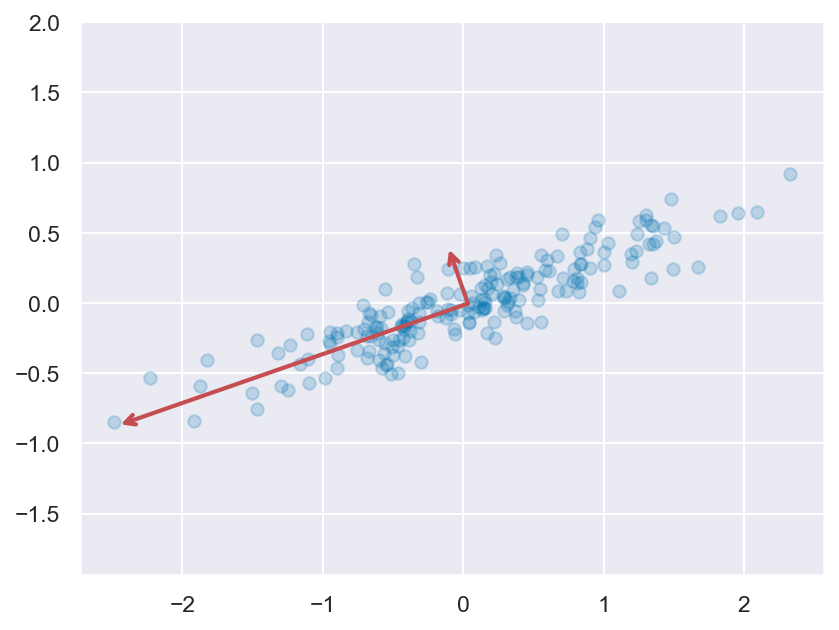

In [6]:
def draw_vector(v0, v1, ax=None): 
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->',linewidth=2,shrinkA=0, shrinkB=0, ec="r")
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# plot data
plt.scatter(X[:, 0], X[:, 1], alpha=0.2)
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
plt.axis('equal');

These vectors represent the principal axes of the data, and the length is an indication of how “important” that axis is in describing the distribution of the data—more precisely, it is a measure of the variance of the data when pro‐ jected onto that axis. The projection of each data point onto the principal axes are the “principal components” of the data.

In [7]:
#Here is an example of using PCA as a dimensionality reduction transform:

pca = PCA(n_components=1)
pca.fit(X)
X_pca = pca.transform(X) 
print("original shape: ", X.shape) 
print("transformed shape:", X_pca.shape)

original shape:  (200, 2)
transformed shape: (200, 1)


The transformed data has been reduced to a single dimension. To understand the effect of this dimensionality reduction, we can perform the inverse transform of this reduced data and plot it along with the original data:

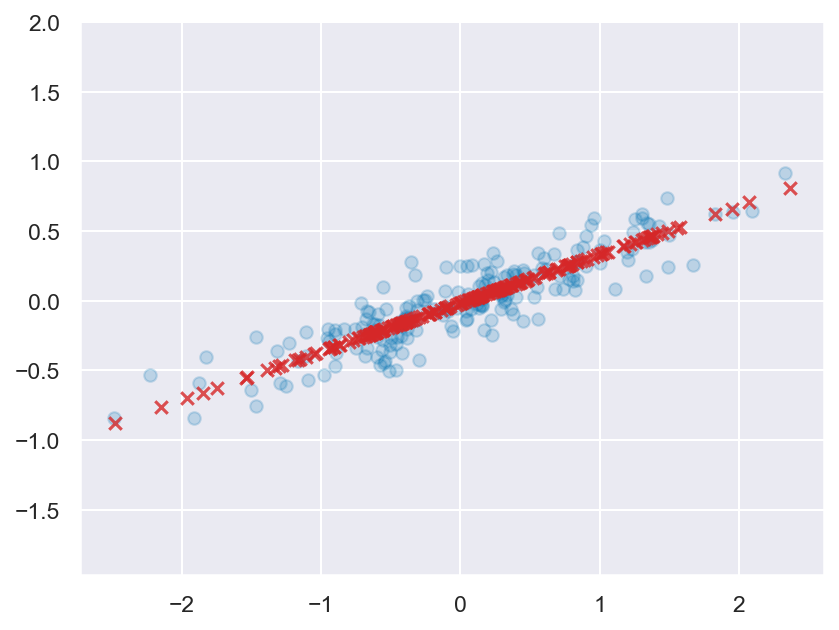

In [8]:
X_new = pca.inverse_transform(X_pca)

plt.scatter(X[:, 0], X[:, 1], alpha=0.2)

plt.scatter(X_new[:, 0], X_new[:, 1], alpha=0.8, marker='x', c='#d62728')
plt.axis('equal');

This makes clear what a PCA dimensionality reduction means: the information along the least important principal axis or axes is removed, leaving only the component(s) of the data with the highest variance.

---
## KMeans clustering

The KMeans algorithm clusters data by trying to separate samples in $K$ groups of equal variance, minimizing a criterion known as the inertia or within-cluster sum-of-squares (see below). This algorithm requires the number of clusters to be specified. It scales well to large number of samples and has been used across a large range of application areas in many different fields.

The k-means algorithm divides a set of $N$ samples $X$ into $K$ disjoint clusters $C$, each described by the mean $\mu_j$ of the samples in the cluster. The means are commonly called the cluster `“centroids”`; note that they are not, in general, points from $X$, although they live in the same space.


In [9]:
from sklearn.cluster import KMeans
import numpy as np # standard way to import numpy

Step 1: Generate random data

Here is the code for generating some random data in a two-dimensional space:


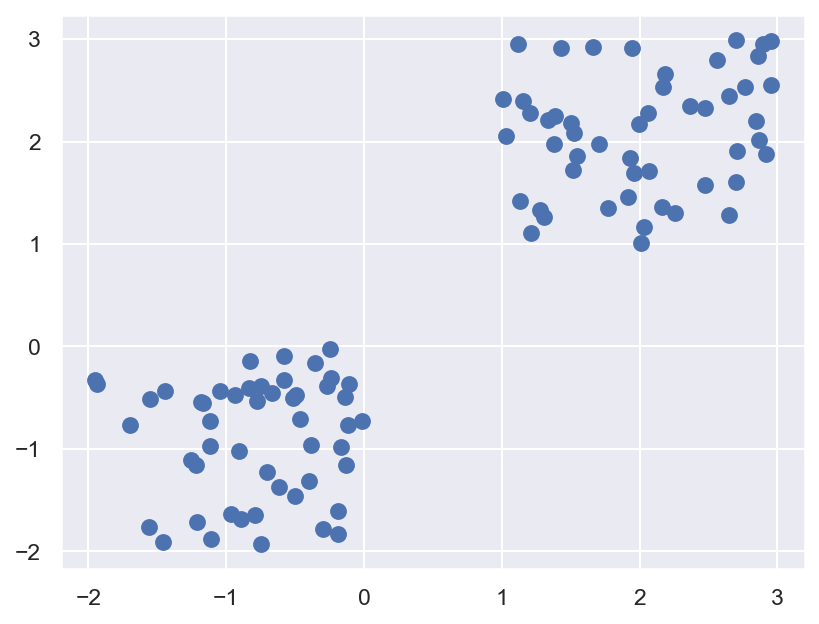

In [10]:
X = -2 * np.random.rand(100,2)
X1 = 1 + 2 * np.random.rand(50,2)
X[50:100, :] = X1

plt.scatter(X[ : , 0], X[ :, 1], s = 50, c = 'b')
plt.show()

Step 2: Use Scikit-Learn

We’ll use some of the available functions in the Scikit-learn library to process the randomly generated data.

In [11]:
Kmean = KMeans(n_clusters=2, random_state=0, n_init="auto")
Kmean.fit(X)

KMeans(n_clusters=2, n_init='auto', random_state=0)

Step 3: Finding the centroid

Here is the code for finding the center of the clusters:



In [12]:
Kmean.cluster_centers_

array([[ 2.00474937,  2.07940086],
       [-0.77652389, -0.88893891]])

Let’s display the cluster centroids (using green and red color).

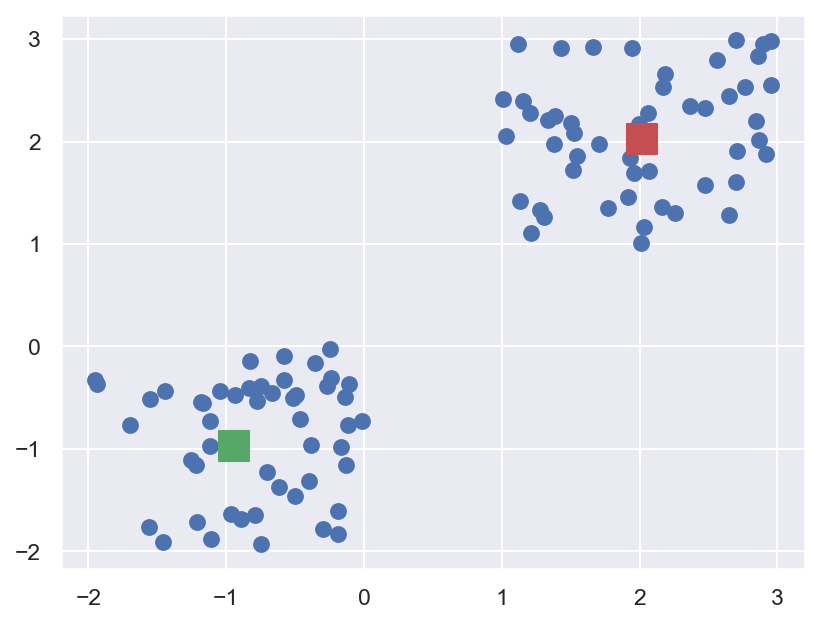

In [13]:
plt.scatter(X[ : , 0], X[ : , 1], s =50, c='b')
plt.scatter(-0.94665068, -0.97138368, s=200, c='g', marker='s')
plt.scatter(2.01559419, 2.02597093, s=200, c='r', marker='s')
plt.show()

Step 4: Testing the algorithm

Here is the code for getting the labels property of the K-means clustering example dataset; that is, how the data points are categorized into the two clusters.

In [14]:
Kmean.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

As you can see above, 50 data points belong to the 0 cluster while the rest belong to the 1 cluster.

In [15]:
sample_test=np.array([0.7,0.7])
# One shape dimension can be -1. In this case, the value 
# is inferred from the length of the array and remaining dimensions.
second_test=sample_test.reshape(1, -1)
Kmean.predict(second_test)

array([0], dtype=int32)

---

### KMeans on synthetic data

This example is meant to illustrate situations where k-means will produce unintuitive and possibly unexpected clusters. In the first three plots, the input data does not conform to some implicit assumption that k-means makes and undesirable clusters are produced as a result. In the last plot, k-means returns intuitive clusters despite unevenly sized blobs.

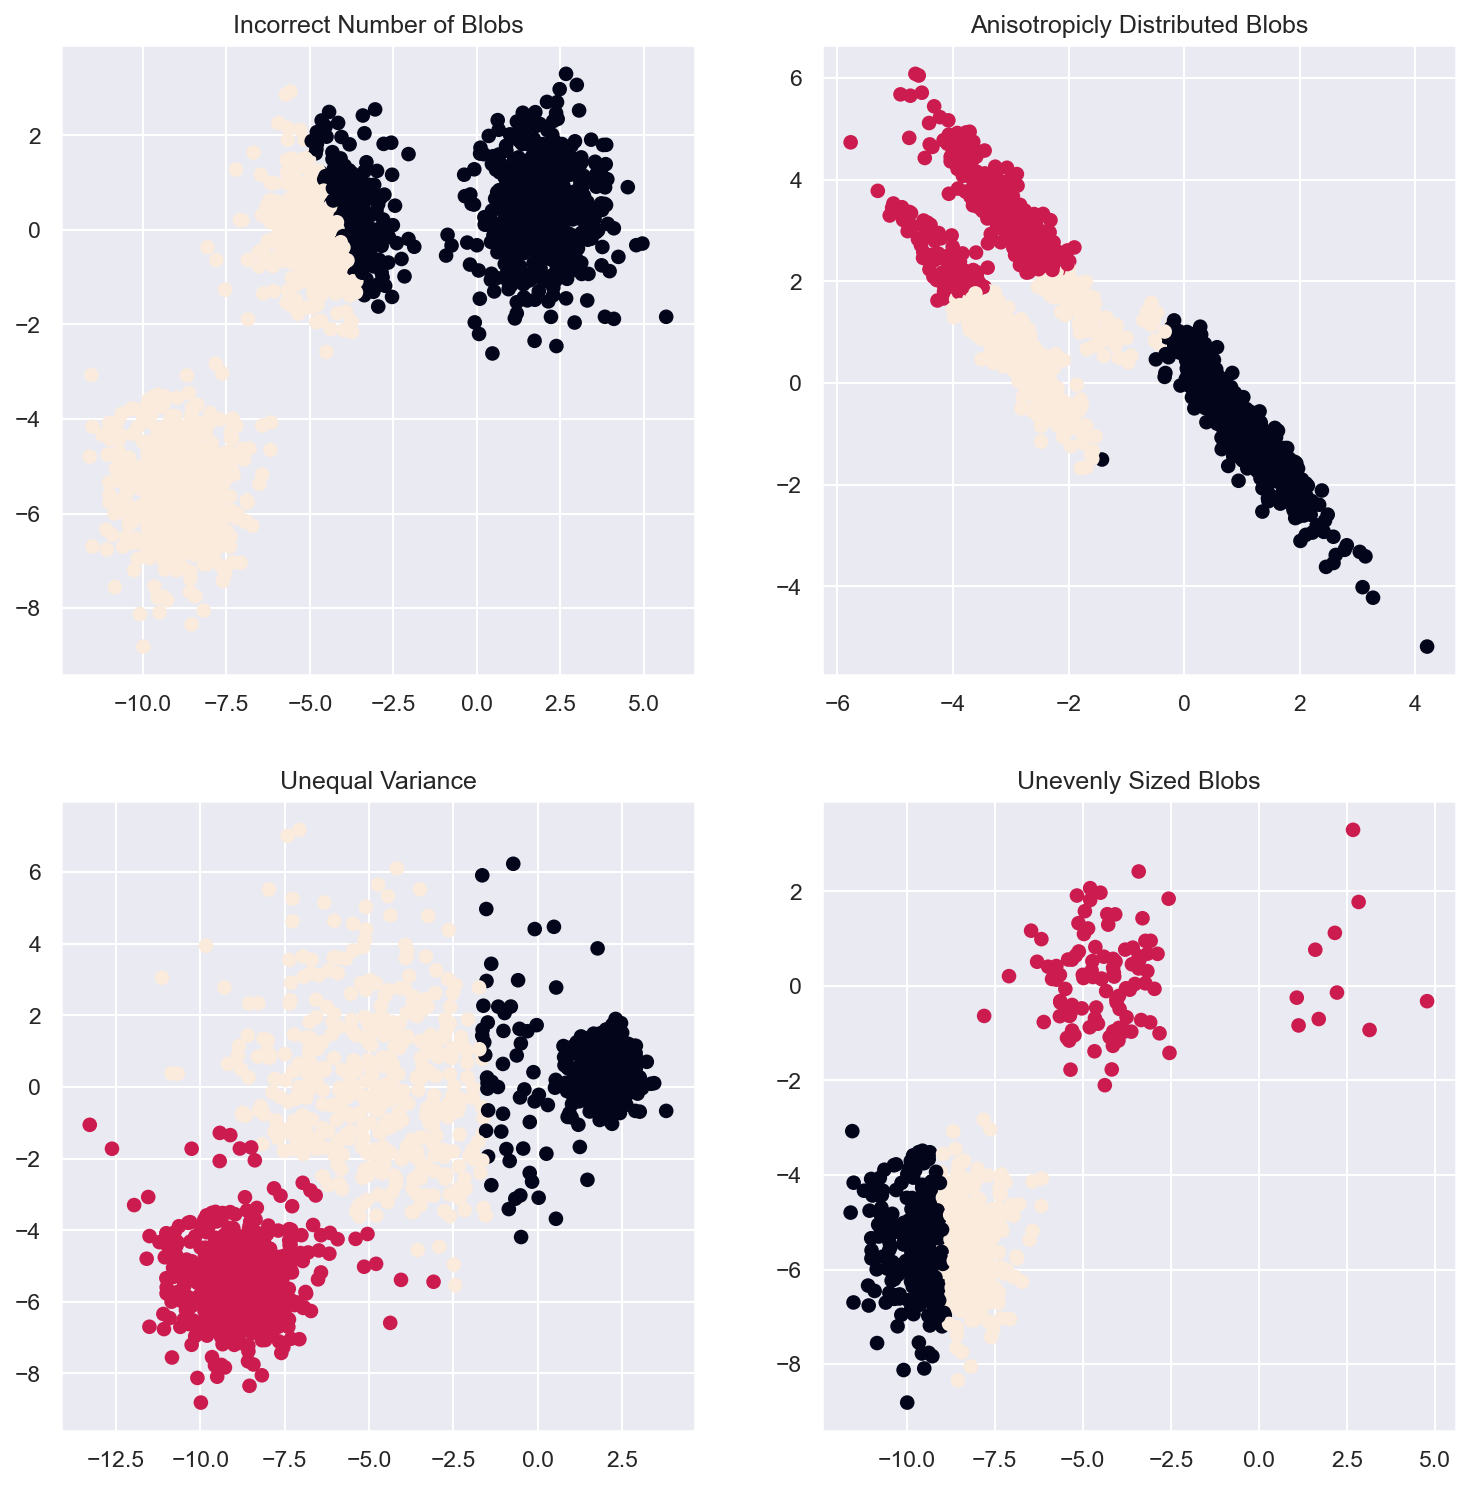

In [16]:
# Author: Phil Roth <mr.phil.roth@gmail.com>
# License: BSD 3 clause

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

plt.figure(figsize=(12, 12))

n_samples = 1500
random_state = 170
X, y = make_blobs(n_samples=n_samples, random_state=random_state)

# Incorrect number of clusters
y_pred = KMeans(n_clusters=2, random_state=random_state, n_init="auto").fit_predict(X)

plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.title("Incorrect Number of Blobs")

# Anisotropicly distributed data
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X, transformation)
y_pred = KMeans(n_clusters=3, random_state=random_state, n_init="auto").fit_predict(X_aniso)

plt.subplot(222)
plt.scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred)
plt.title("Anisotropicly Distributed Blobs")

# Different variance
X_varied, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)
y_pred = KMeans(n_clusters=3, random_state=random_state,n_init="auto").fit_predict(X_varied)

plt.subplot(223)
plt.scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred)
plt.title("Unequal Variance")

# Unevenly sized blobs
X_filtered = np.vstack((X[y == 0][:500], X[y == 1][:100], X[y == 2][:10]))
y_pred = KMeans(n_clusters=3, random_state=random_state, n_init="auto").fit_predict(X_filtered)

plt.subplot(224)
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
plt.title("Unevenly Sized Blobs")

plt.show()

## Hierchical Clustering

This example shows characteristics of different linkage methods for hierarchical clustering on datasets that are “interesting” but still in 2D.

The main observations to make are:

single linkage is fast, and can perform well on non-globular data, but it performs poorly in the presence of noise.

average and complete linkage perform well on cleanly separated globular clusters, but have mixed results otherwise.

Ward is the most effective method for noisy data.

While these examples give some intuition about the algorithms, this intuition might not apply to very high dimensional data.



In [17]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice

np.random.seed(0)

Generate datasets. We choose the size big enough to see the scalability of the algorithms, but not too big to avoid too long running times



In [18]:
n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
no_structure = np.random.rand(n_samples, 2), None

# Anisotropicly distributed data
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# blobs with varied variances
varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)


Run the clustering and plot



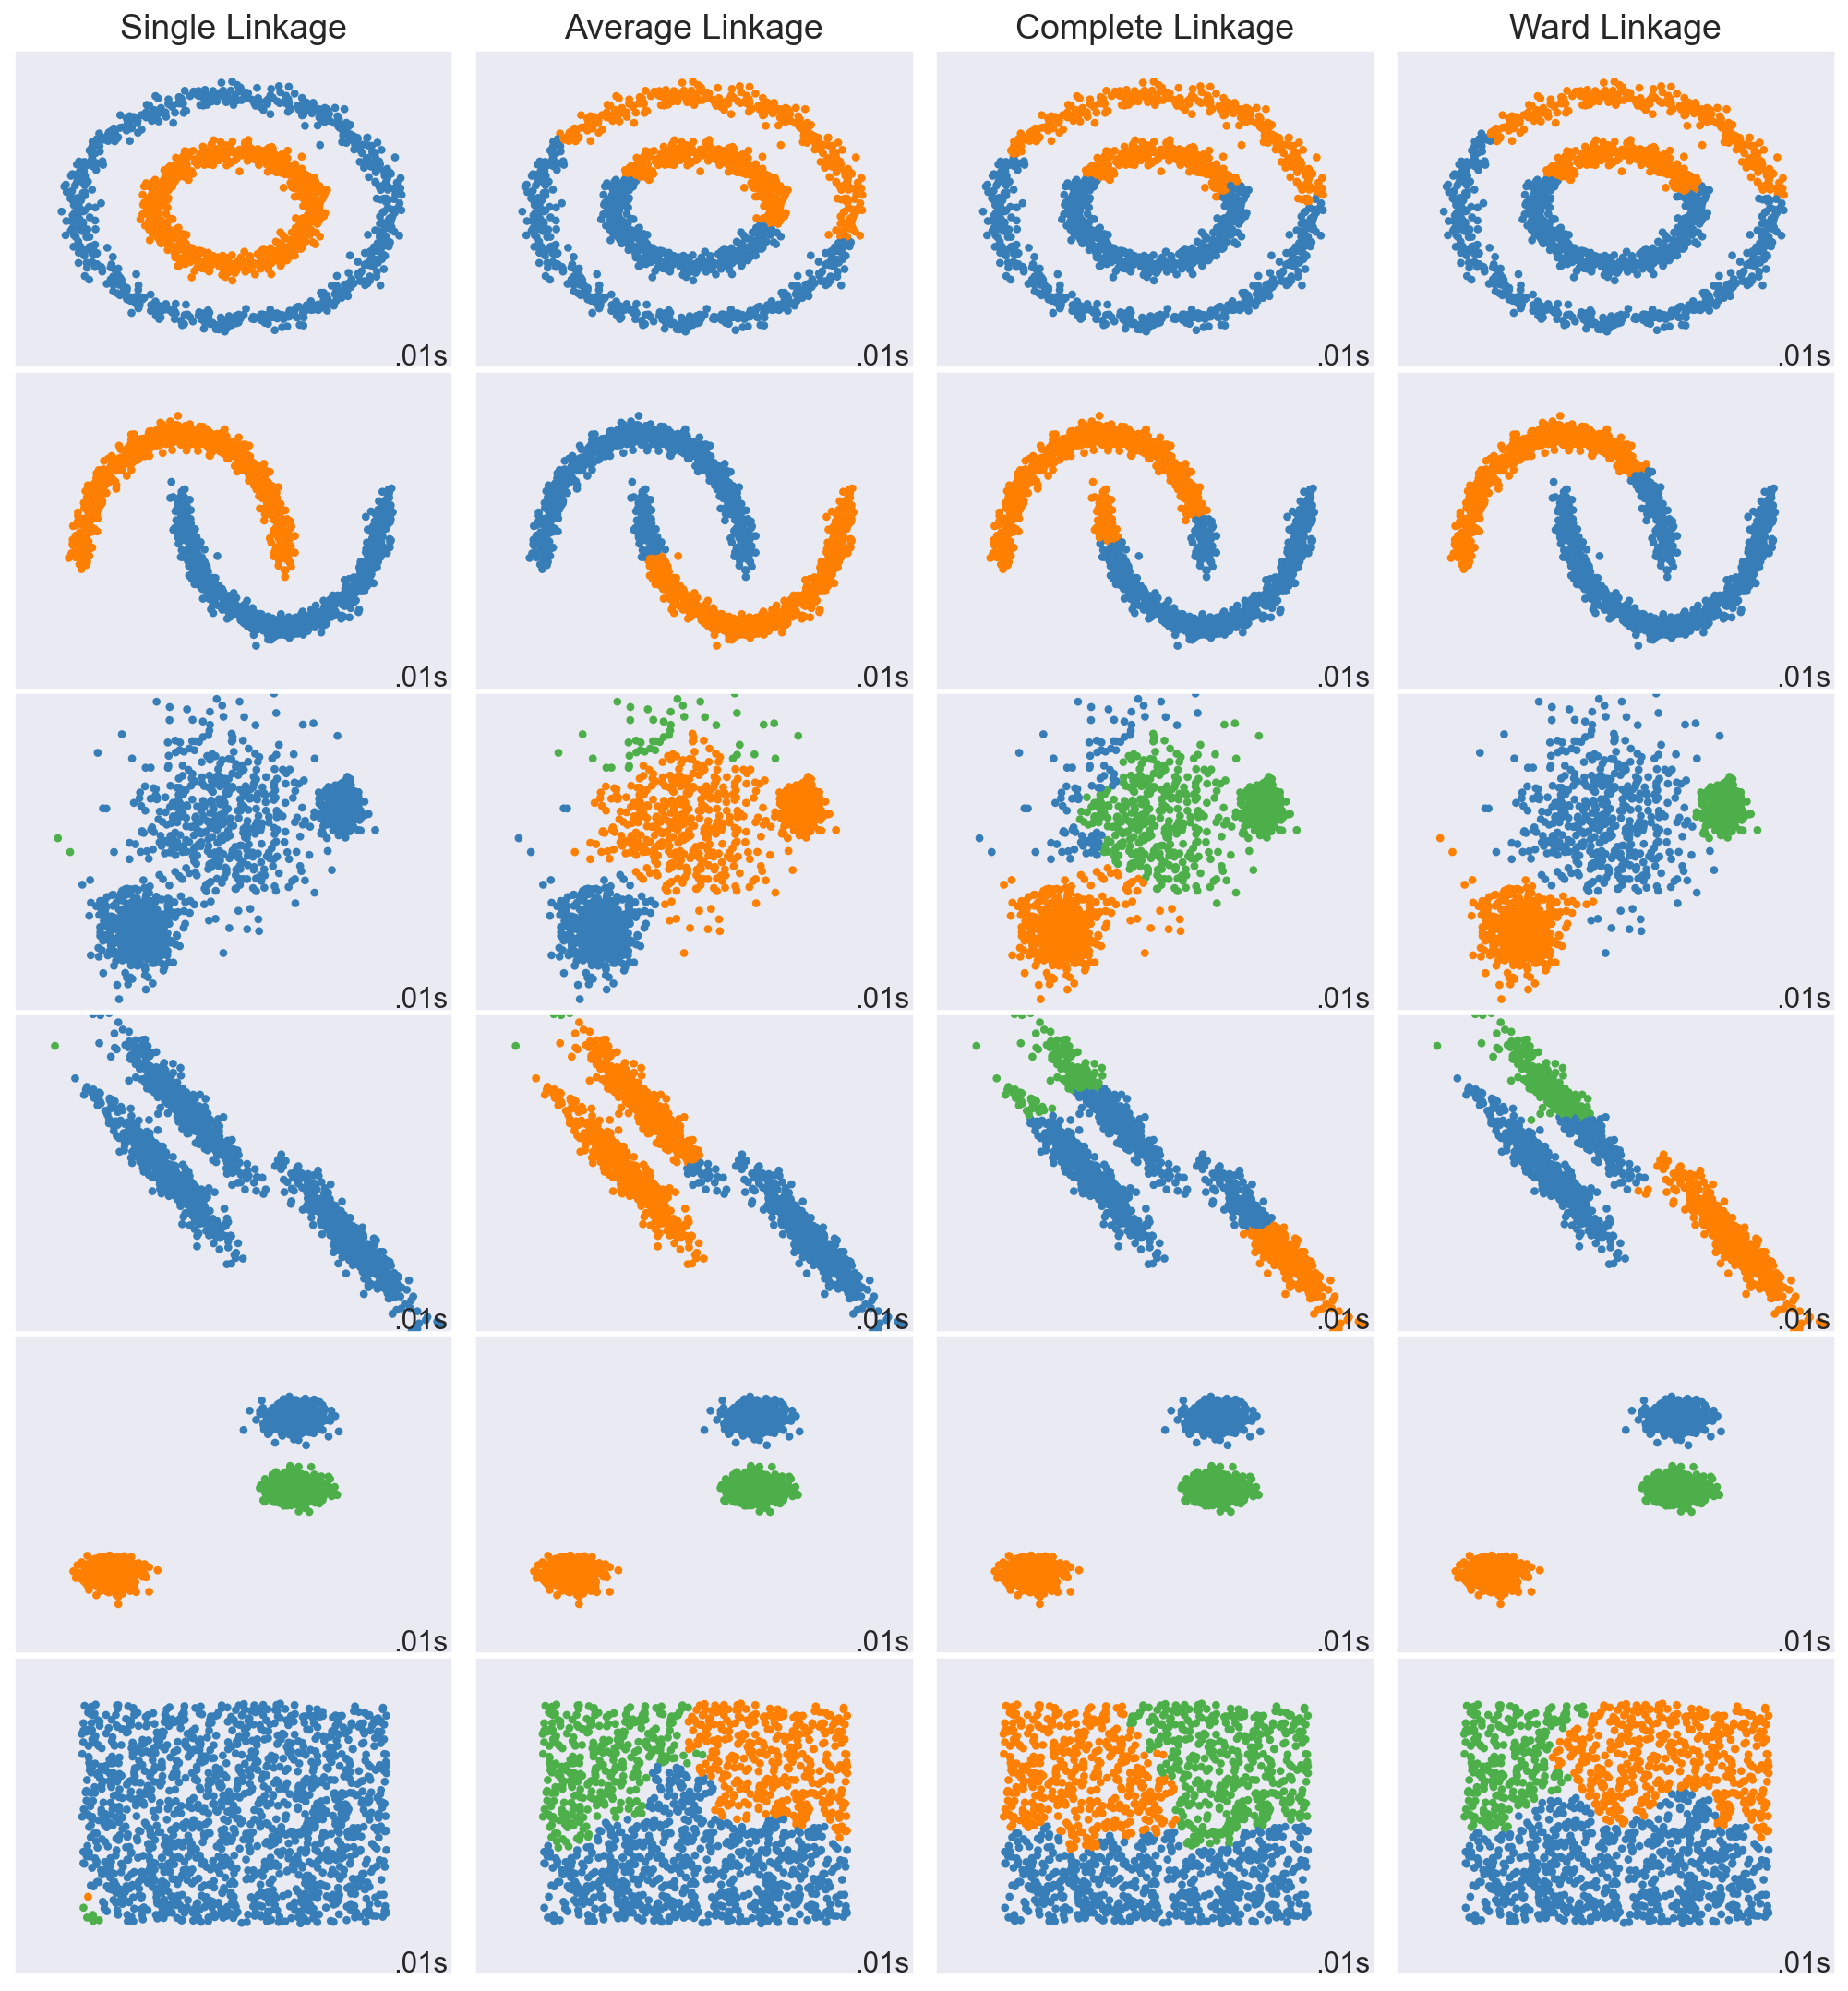

In [19]:
# Set up cluster parameters
plt.figure(figsize=(9 * 1.3 + 2, 14.5))
plt.subplots_adjust(
    left=0.02, right=0.98, bottom=0.001, top=0.96, wspace=0.05, hspace=0.01
)

plot_num = 1

default_base = {"n_neighbors": 10, "n_clusters": 3}

datasets = [
    (noisy_circles, {"n_clusters": 2}),
    (noisy_moons, {"n_clusters": 2}),
    (varied, {"n_neighbors": 2}),
    (aniso, {"n_neighbors": 2}),
    (blobs, {}),
    (no_structure, {}),
]

for i_dataset, (dataset, algo_params) in enumerate(datasets):
    # update parameters with dataset-specific values
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset

    # normalize dataset for easier parameter selection
    X = StandardScaler().fit_transform(X)

    # ============
    # Create cluster objects
    # ============
    ward = cluster.AgglomerativeClustering(
        n_clusters=params["n_clusters"], linkage="ward"
    )
    complete = cluster.AgglomerativeClustering(
        n_clusters=params["n_clusters"], linkage="complete"
    )
    average = cluster.AgglomerativeClustering(
        n_clusters=params["n_clusters"], linkage="average"
    )
    single = cluster.AgglomerativeClustering(
        n_clusters=params["n_clusters"], linkage="single"
    )

    clustering_algorithms = (
        ("Single Linkage", single),
        ("Average Linkage", average),
        ("Complete Linkage", complete),
        ("Ward Linkage", ward),
    )

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        # catch warnings related to kneighbors_graph
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="the number of connected components of the "
                + "connectivity matrix is [0-9]{1,2}"
                + " > 1. Completing it to avoid stopping the tree early.",
                category=UserWarning,
            )
            algorithm.fit(X)

        t1 = time.time()
        if hasattr(algorithm, "labels_"):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        plt.subplot(len(datasets), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=18)

        colors = np.array(
            list(
                islice(
                    cycle(
                        [
                            "#377eb8",
                            "#ff7f00",
                            "#4daf4a",
                            "#f781bf",
                            "#a65628",
                            "#984ea3",
                            "#999999",
                            "#e41a1c",
                            "#dede00",
                        ]
                    ),
                    int(max(y_pred) + 1),
                )
            )
        )
        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])

        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plt.text(
            0.99,
            0.01,
            ("%.2fs" % (t1 - t0)).lstrip("0"),
            transform=plt.gca().transAxes,
            size=15,
            horizontalalignment="right",
        )
        plot_num += 1

plt.show()


# Decision tree methods. 

You need to install `Numpy`, `Pandas`, `seaborn`, `scikit-learn` packages in order to run the notebook


---

All course materials, including all lecture notes and python notebooks, are for your own educational purposes only. All the contents of the materials are protected by copyright, trademark or other forms of proprietary rights.
All rights, title and interest in the materials are owned by, licensed to or controlled by the University (i.e., Nanyang Technological University), unless otherwise expressly stated. The materials shall not be uploaded, reproduced, distributed, republished or transmitted in any form or by any means, in whole or in part, without written approval from the University.

---

# Decision Tree Regression

---
All course materials, including all lecture notes and python notebooks, are for your own educational purposes only. All the contents of the materials are protected by copyright, trademark or other forms of proprietary rights.
All rights, title and interest in the materials are owned by, licensed to or controlled by the University, unless otherwise expressly stated. The materials shall not be uploaded, reproduced, distributed, republished or transmitted in any form or by any means, in whole or in part, without written approval from the University.

---

Decision trees can also be applied to regression problems, using the DecisionTreeRegressor class.

As in the classification setting, the fit method will take as argument arrays X and y, only that in this case y is expected to have floating point values instead of integer values.


A 1D regression with decision tree.

The decision trees is used to fit a sine curve with addition noisy observation. As a result, it learns local linear regressions approximating the sine curve.

We can see that if the maximum depth of the tree (controlled by the max_depth parameter) is set too high, the decision trees learn too fine details of the training data and learn from the noise, i.e. they overfit.

In [20]:
# Load libraries

# Import the necessary modules and libraries
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier 
from sklearn import datasets
from sklearn import tree

plt.rcParams['figure.dpi'] = 200 # set resolution of output plots


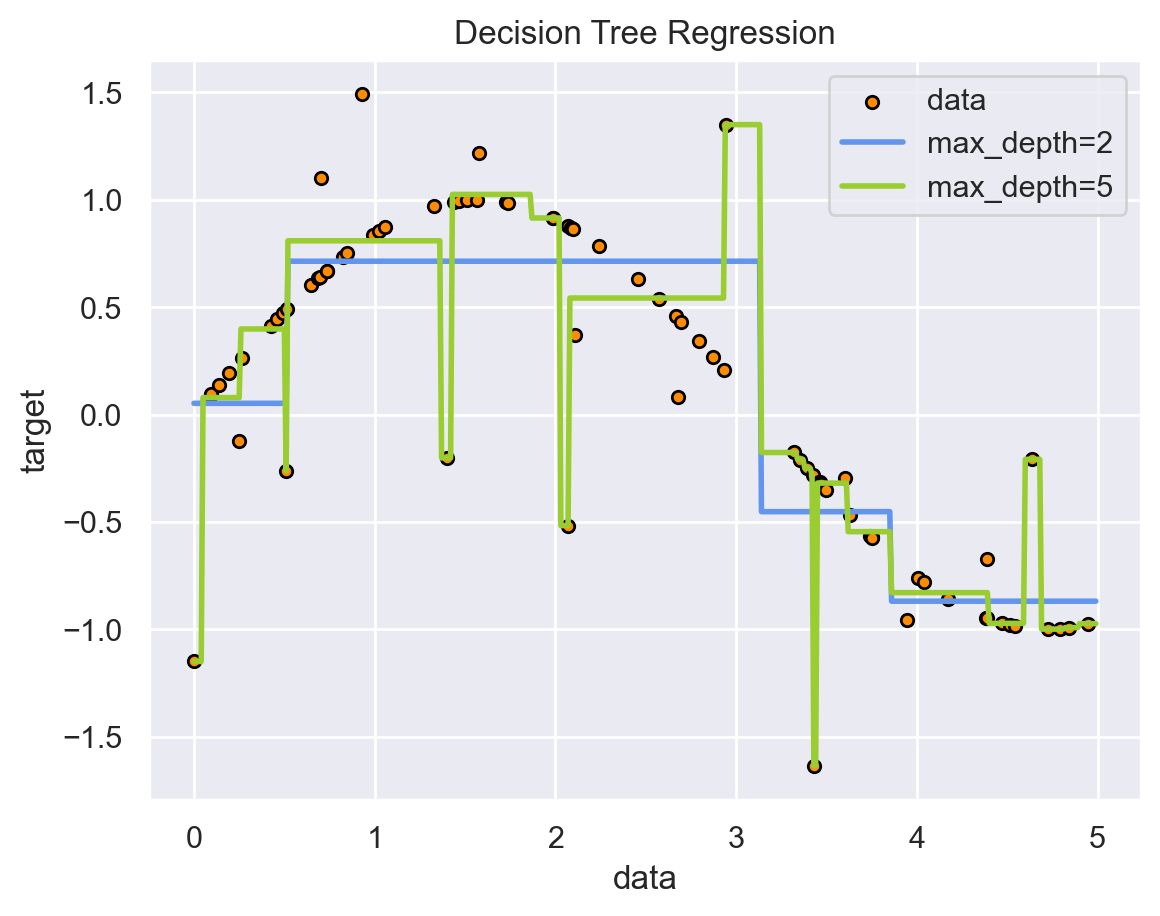

In [21]:
# Create a random dataset
rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))

# Fit regression model
regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_1.fit(X, y)
regr_2.fit(X, y)

# Predict
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)

# Plot the results
plt.figure()
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=2", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

### Fast and slow oscillation

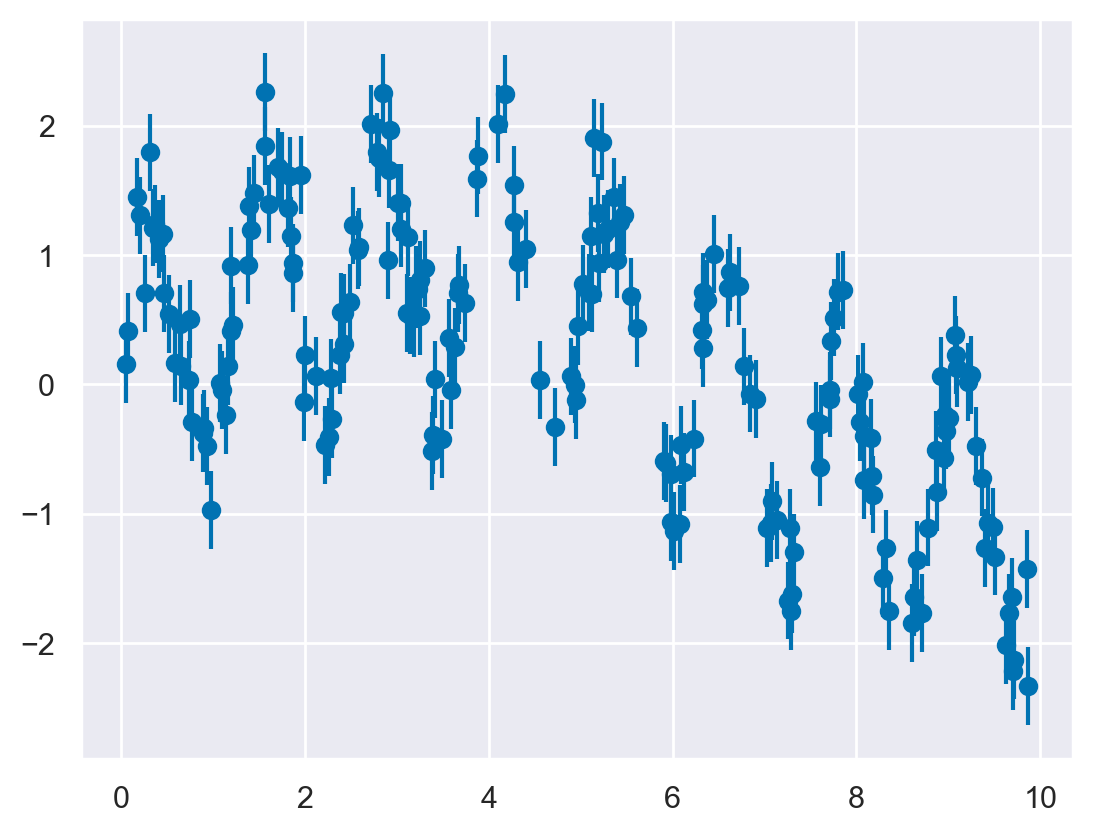

In [22]:
rng = np.random.RandomState(42)

x = 10 * rng.rand(200)

def model(x, sigma=0.3): 
    fast_oscillation = np.sin(5 * x) 
    slow_oscillation = np.sin(0.5 * x) 
    noise = sigma * rng.randn(len(x))
    return slow_oscillation + fast_oscillation + noise 

y = model(x)
plt.errorbar(x, y, 0.3, fmt='o');

Use the random forest regressor to find the best-fit curve:

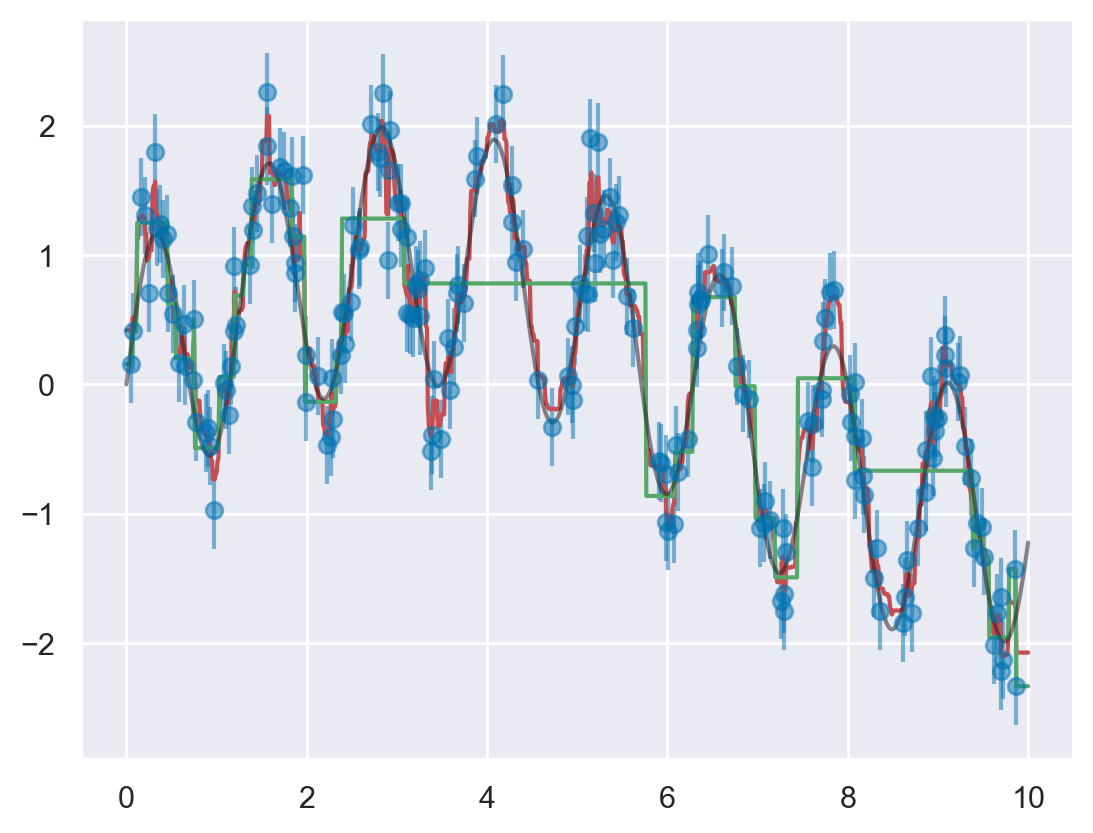

In [23]:
from sklearn.ensemble import RandomForestRegressor 

regr = DecisionTreeRegressor(max_depth=5)
regr.fit(x[:, None], y)

xfit = np.linspace(0, 10, 1000)
yreg = regr.predict(xfit[:, None])


forest = RandomForestRegressor(200) 
forest.fit(x[:, None], y)
            
    
yfor = forest.predict(xfit[:, None])
ytrue = model(xfit, sigma=0)
            
    
plt.errorbar(x, y, 0.3, fmt='o', alpha=0.5)
plt.plot(xfit, yfor, '-r');
plt.plot(xfit, yreg, '-g');
plt.plot(xfit, ytrue, '-k', alpha=0.5);

Here the true model is shown by the smooth curve, while the random forest model is shown by the jagged curve. As you can see, the nonparametric random forest model is flexible enough to fit the multiperiod data, without us needing to specify a multi‐ period model!

# Decision Trees Classification

`DecisionTreeClassifier` is a class capable of performing multi-class classification on a dataset.

As with other classifiers, `DecisionTreeClassifier` takes as input two arrays: an array X, sparse or dense, of shape (n_samples, n_features) holding the training samples, and an array Y of integer values, shape (n_samples,), holding the class labels for the training samples:

## Understanding the decision tree structure

The decision tree structure can be analysed to gain further insight on the relation between the features and the target to predict. In this example, we show how to retrieve:

the binary tree structure;

the depth of each node and whether or not it’s a leaf;

the nodes that were reached by a sample using the decision_path method;

the leaf that was reached by a sample using the apply method;

the rules that were used to predict a sample;

the decision path shared by a group of samples.

In [24]:
# Load data
iris = datasets.load_iris()


X, y = iris.data, iris.target
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, y)

Once trained, you can plot the tree with the plot_tree function:

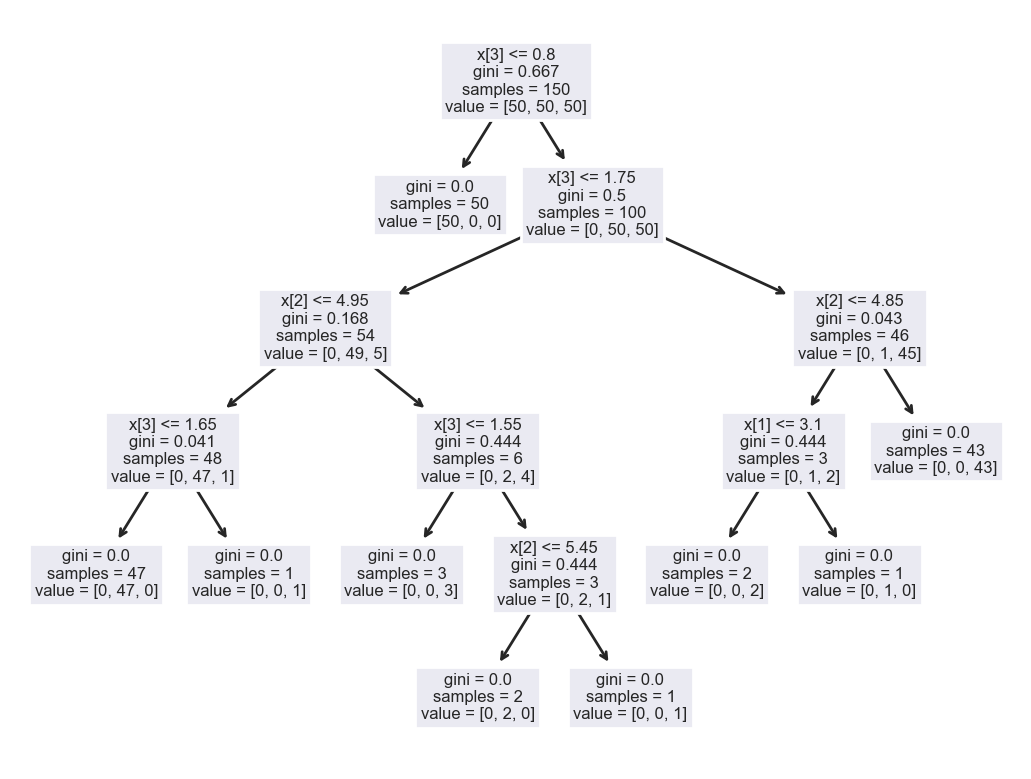

In [25]:
tree.plot_tree(clf)
plt.show()

## Synthetic Blob Data

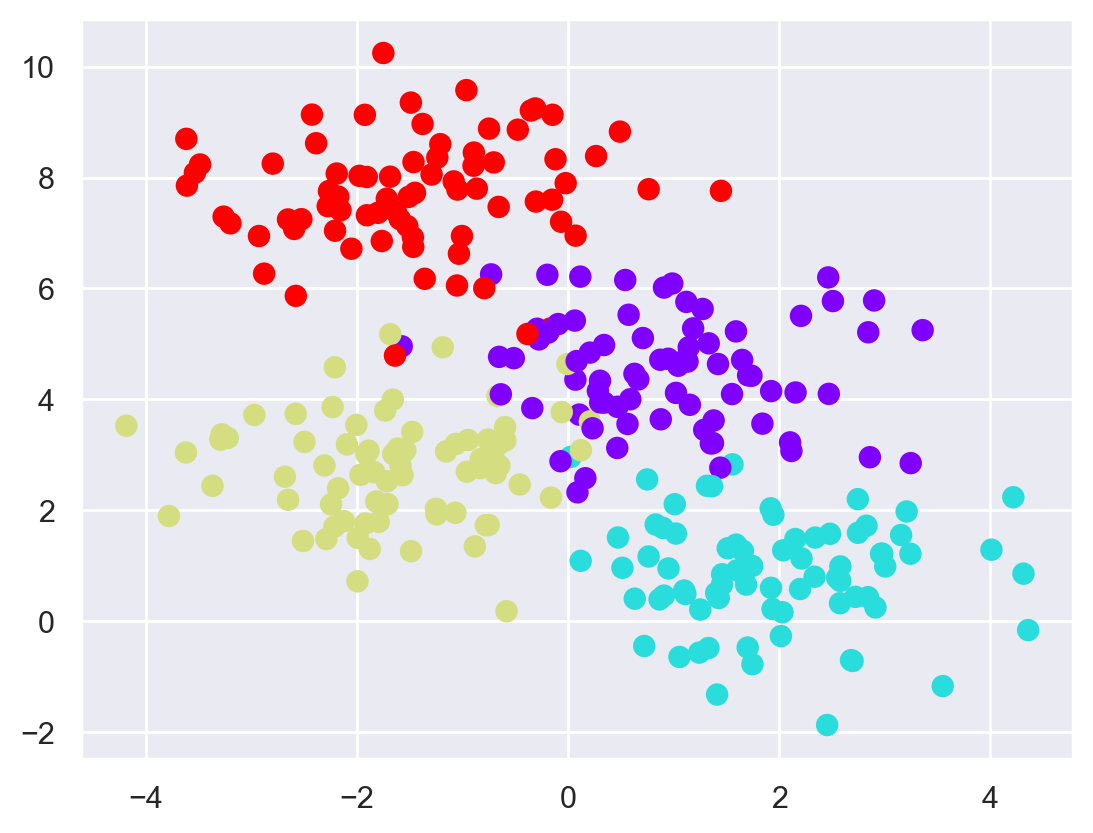

In [26]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4,random_state=0, cluster_std=1.0)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');

In [27]:
from sklearn.tree import DecisionTreeClassifier 

tree = DecisionTreeClassifier().fit(X, y)

In [28]:
def visualize_classifier(model, X, y, ax=None, cmap='rainbow'): 
    ax = ax or plt.gca()
    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,levels=np.arange(n_classes + 1) - 0.5, cmap=cmap, clim=(y.min(), y.max()),zorder=1)
    ax.set(xlim=xlim, ylim=ylim)

/var/folders/jh/99v6v3d928j5sdbfx982j9kw0000gn/T/ipykernel_69221/685989398.py:15: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,levels=np.arange(n_classes + 1) - 0.5, cmap=cmap, clim=(y.min(), y.max()),zorder=1)


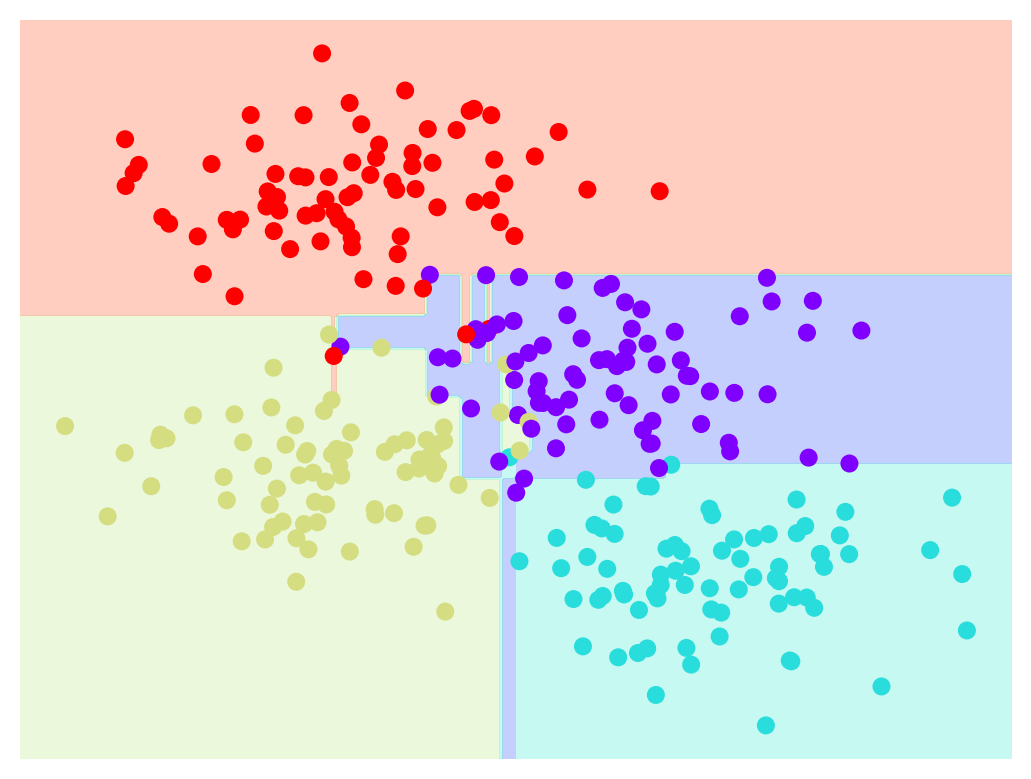

In [29]:
visualize_classifier(DecisionTreeClassifier(), X, y)

Notice that as the depth increases, we tend to get very strangely shaped classification regions. Such overfitting turns out to be a general property of decision trees; it is very easy to go too deep in the tree, and thus to fit details of the particular data rather than the overall properties of the distributions they are drawn from. 

# Ensembles of Estimators: Bagging

Bagging classification done using Scikit-Learn’s `BaggingClassifier`

/var/folders/jh/99v6v3d928j5sdbfx982j9kw0000gn/T/ipykernel_69221/685989398.py:15: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,levels=np.arange(n_classes + 1) - 0.5, cmap=cmap, clim=(y.min(), y.max()),zorder=1)


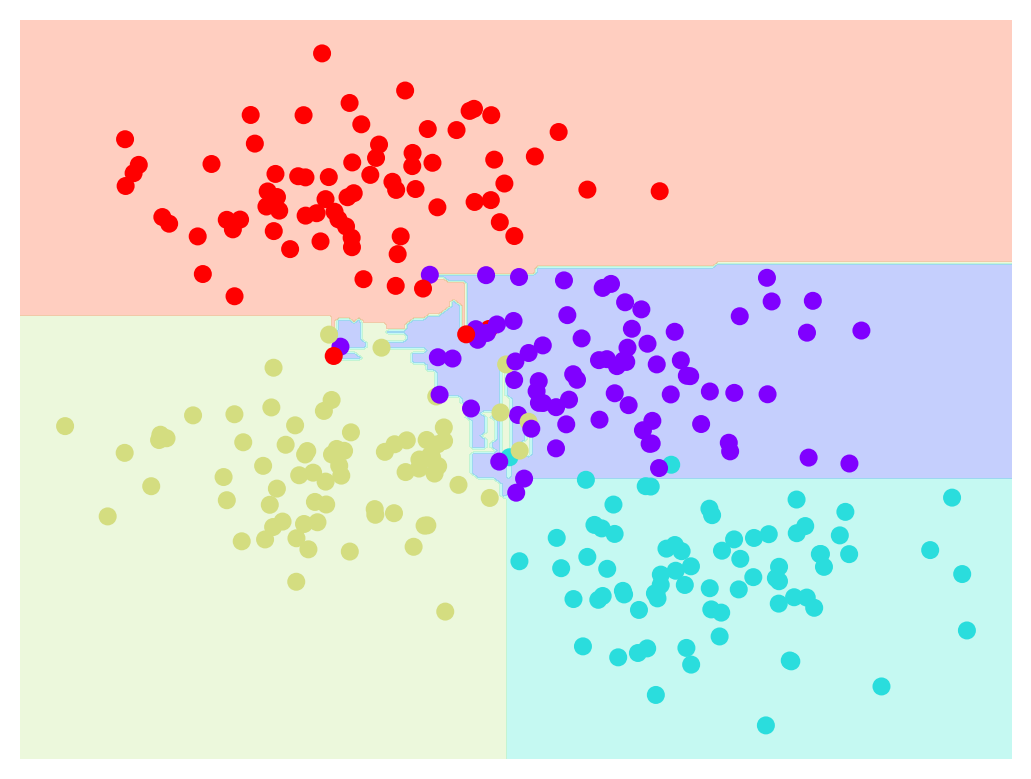

In [30]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import BaggingClassifier
           
tree = DecisionTreeClassifier()
bag = BaggingClassifier(tree, n_estimators=100, max_samples=0.8,random_state=1)

bag.fit(X, y)
visualize_classifier(bag, X, y)

# Ensembles of Estimators: Random Forests

An optimized ensemble of randomized decision trees is implemented in the `RandomForestClassifier` estimator, which takes care of all the randomization automatically. 

/var/folders/jh/99v6v3d928j5sdbfx982j9kw0000gn/T/ipykernel_69221/685989398.py:15: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,levels=np.arange(n_classes + 1) - 0.5, cmap=cmap, clim=(y.min(), y.max()),zorder=1)


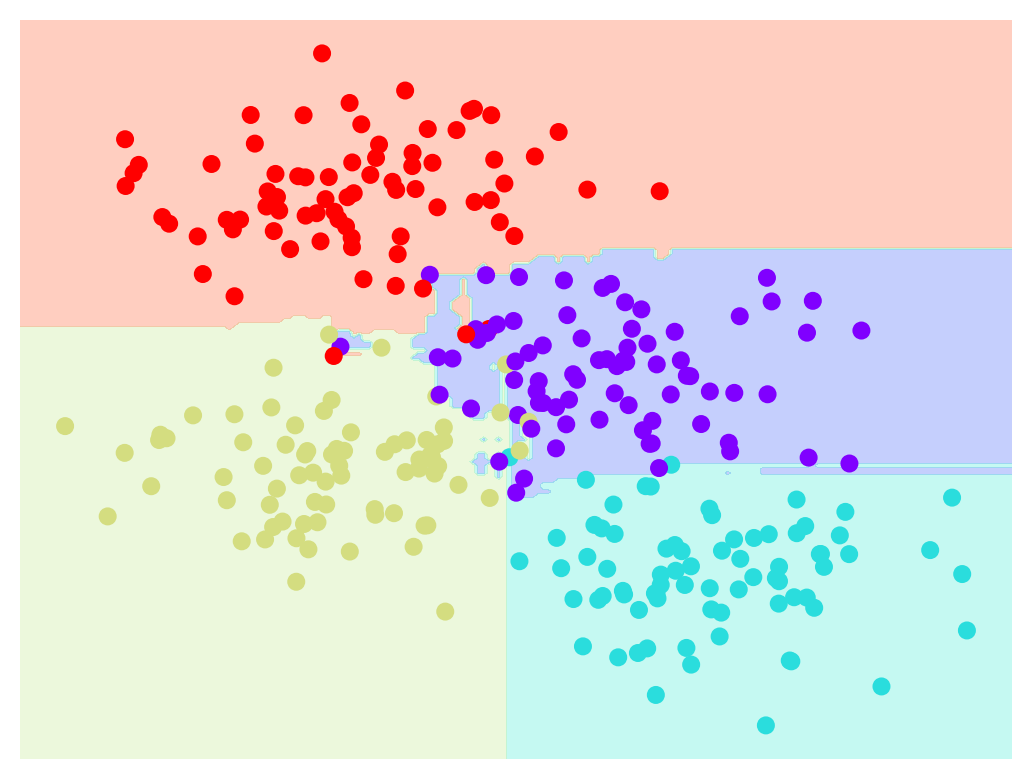

In [31]:
from sklearn.ensemble import RandomForestClassifier
           
model = RandomForestClassifier(n_estimators=100, random_state=0)
visualize_classifier(model, X, y);

We see that by averaging over 100 randomly perturbed models, we end up with an overall model that is much closer to our intuition about how the parameter space should be split.

## Random Forest for Classifying Digits

In [32]:
from sklearn.datasets import load_digits 

digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

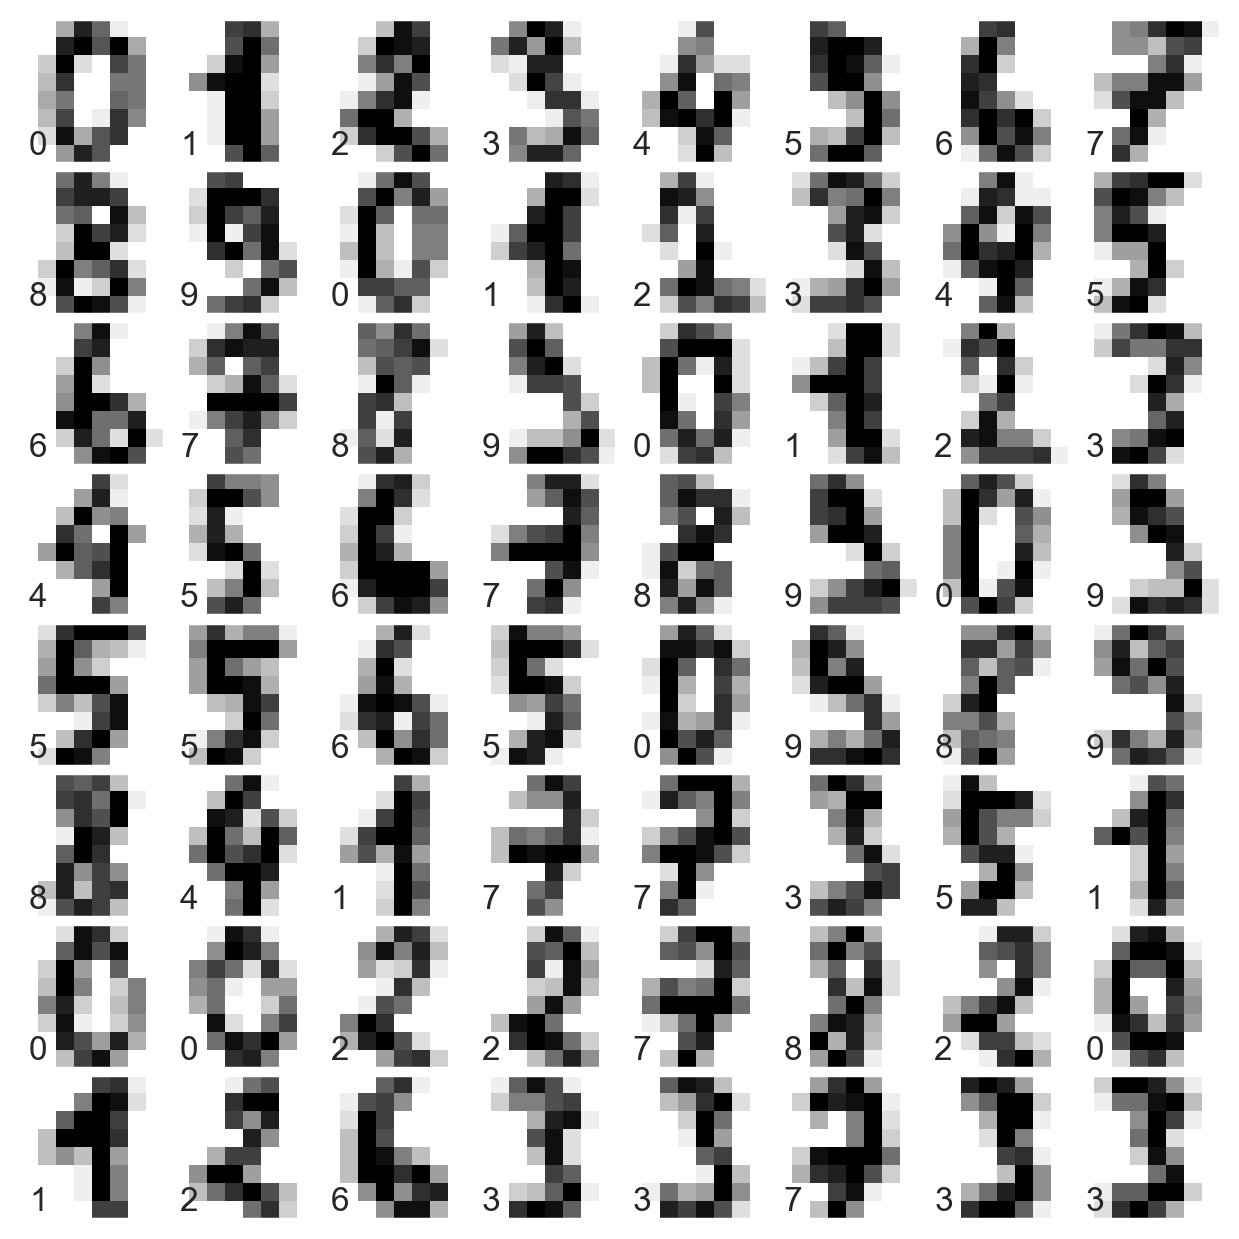

In [33]:
# set up the figure
fig = plt.figure(figsize=(6, 6)) # figure size in inches 
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# plot the digits: each image is 8x8 pixels
for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[]) 
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')
    
    # label the image with the target value
    ax.text(0, 7, str(digits.target[i]))

In [34]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data, digits.target,random_state=0)
    
model = RandomForestClassifier(n_estimators=1000)
model.fit(Xtrain, ytrain)
ypred = model.predict(Xtest)

In [35]:
from sklearn import metrics 

print(metrics.classification_report(ypred, ytest))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        38
           1       1.00      0.98      0.99        44
           2       0.95      1.00      0.98        42
           3       0.98      0.96      0.97        46
           4       0.97      1.00      0.99        37
           5       0.98      0.98      0.98        48
           6       1.00      1.00      1.00        52
           7       1.00      0.96      0.98        50
           8       0.94      0.98      0.96        46
           9       0.98      0.98      0.98        47

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



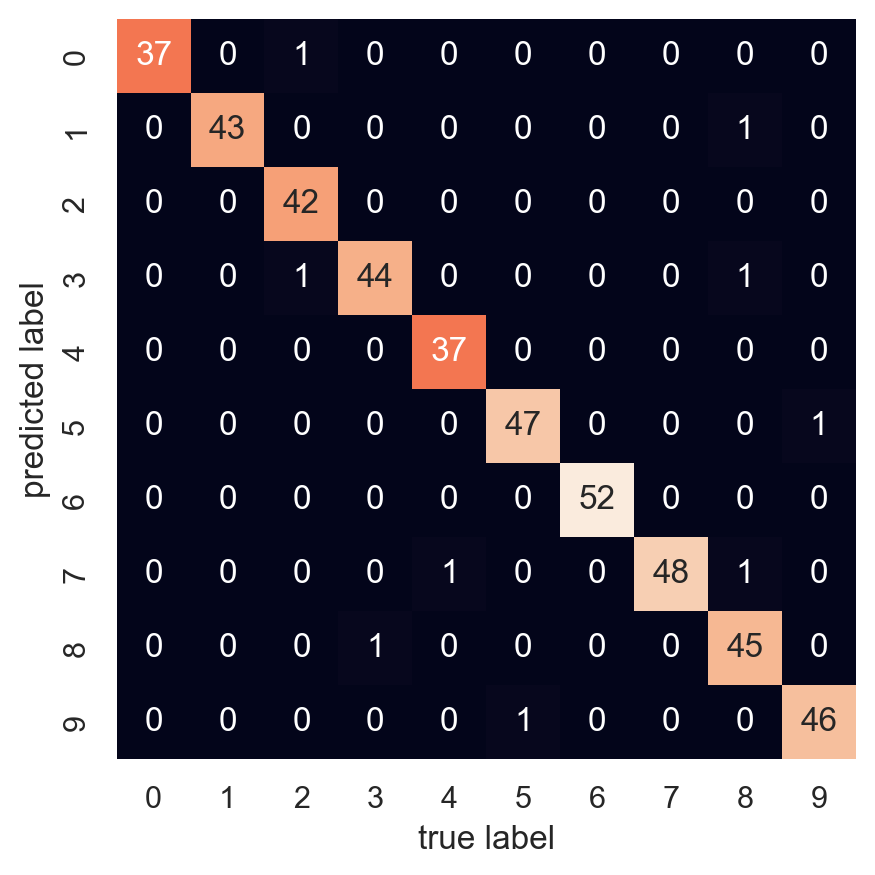

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sb

mat = confusion_matrix(ytest, ypred)
sb.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False) 
plt.xlabel('true label')
plt.ylabel('predicted label');

## Evaluating Random Forests with Out-of-Bag Errors

In [37]:
# Load data
iris = datasets.load_iris()

features = iris.data
target = iris.target

# Create random tree classifier object

randomforest = RandomForestClassifier(random_state=0, n_estimators=1000, oob_score=True, n_jobs=-1)

# Train model
model = randomforest.fit(features, target) # View out-of-bag-error

In [38]:
randomforest.oob_score_

0.9533333333333334

# Iris dataset
Plot the decision surfaces of ensembles of trees on the iris dataset

Plot the decision surfaces of forests of randomized trees trained on pairs of features of the iris dataset.

This plot compares the decision surfaces learned by a decision tree classifier (first column), by a random forest classifier (second column), by an extra- trees classifier (third column) and by an AdaBoost classifier (fourth column).

In the first row, the classifiers are built using the sepal width and the sepal length features only, on the second row using the petal length and sepal length only, and on the third row using the petal width and the petal length only.

In descending order of quality, when trained (outside of this example) on all 4 features using 30 estimators and scored using 10 fold cross validation, we see:

`ExtraTreesClassifier()`  # 0.95 score

`RandomForestClassifier()`  # 0.94 score

`AdaBoost(DecisionTree(max_depth=3))`  # 0.94 score

`DecisionTree(max_depth=None)`  # 0.94 score

Increasing max_depth for AdaBoost lowers the standard deviation of the scores (but the average score does not improve).

See the console’s output for further details about each model.

In this example you might try to:

vary the `max_depth` for the `DecisionTreeClassifier` and `AdaBoostClassifier`, perhaps try `max_depth=3` for the `DecisionTreeClassifier` or `max_depth=None` for `AdaBoostClassifier`

vary n_estimators

It is worth noting that RandomForests and ExtraTrees can be fitted in parallel on many cores as each tree is built independently of the others. AdaBoost’s samples are built sequentially and so do not use multiple cores.



DecisionTree with features [0, 1] has a score of 0.9266666666666666
RandomForest with 30 estimators with features [0, 1] has a score of 0.9266666666666666
ExtraTrees with 30 estimators with features [0, 1] has a score of 0.9266666666666666
AdaBoost with 30 estimators with features [0, 1] has a score of 0.8666666666666667
DecisionTree with features [0, 2] has a score of 0.9933333333333333
RandomForest with 30 estimators with features [0, 2] has a score of 0.9933333333333333
ExtraTrees with 30 estimators with features [0, 2] has a score of 0.9933333333333333
AdaBoost with 30 estimators with features [0, 2] has a score of 0.9933333333333333
DecisionTree with features [2, 3] has a score of 0.9933333333333333
RandomForest with 30 estimators with features [2, 3] has a score of 0.9933333333333333
ExtraTrees with 30 estimators with features [2, 3] has a score of 0.9933333333333333
AdaBoost with 30 estimators with features [2, 3] has a score of 0.9933333333333333


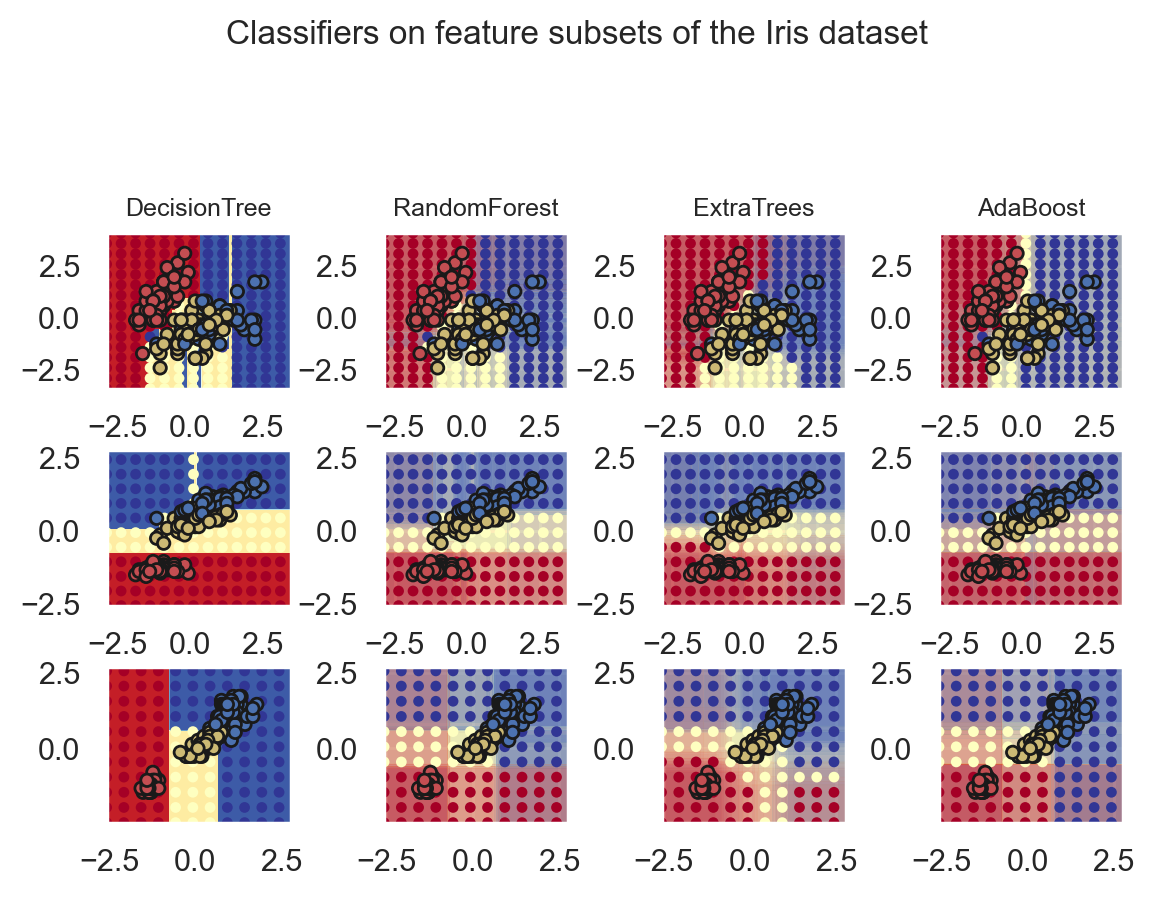

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_iris
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
)
from sklearn.tree import DecisionTreeClassifier

# Parameters
n_classes = 3
n_estimators = 30
cmap = plt.cm.RdYlBu
plot_step = 0.02  # fine step width for decision surface contours
plot_step_coarser = 0.5  # step widths for coarse classifier guesses
RANDOM_SEED = 13  # fix the seed on each iteration

# Load data
iris = load_iris()

plot_idx = 1

models = [
    DecisionTreeClassifier(max_depth=None),
    RandomForestClassifier(n_estimators=n_estimators),
    ExtraTreesClassifier(n_estimators=n_estimators),
    AdaBoostClassifier(DecisionTreeClassifier(max_depth=3), n_estimators=n_estimators),
]

for pair in ([0, 1], [0, 2], [2, 3]):
    for model in models:
        # We only take the two corresponding features
        X = iris.data[:, pair]
        y = iris.target

        # Shuffle
        idx = np.arange(X.shape[0])
        np.random.seed(RANDOM_SEED)
        np.random.shuffle(idx)
        X = X[idx]
        y = y[idx]

        # Standardize
        mean = X.mean(axis=0)
        std = X.std(axis=0)
        X = (X - mean) / std

        # Train
        model.fit(X, y)

        scores = model.score(X, y)
        # Create a title for each column and the console by using str() and
        # slicing away useless parts of the string
        model_title = str(type(model)).split(".")[-1][:-2][: -len("Classifier")]

        model_details = model_title
        if hasattr(model, "estimators_"):
            model_details += " with {} estimators".format(len(model.estimators_))
        print(model_details + " with features", pair, "has a score of", scores)

        plt.subplot(3, 4, plot_idx)
        if plot_idx <= len(models):
            # Add a title at the top of each column
            plt.title(model_title, fontsize=9)

        # Now plot the decision boundary using a fine mesh as input to a
        # filled contour plot
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(
            np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step)
        )

        # Plot either a single DecisionTreeClassifier or alpha blend the
        # decision surfaces of the ensemble of classifiers
        if isinstance(model, DecisionTreeClassifier):
            Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)
            cs = plt.contourf(xx, yy, Z, cmap=cmap)
        else:
            # Choose alpha blend level with respect to the number
            # of estimators
            # that are in use (noting that AdaBoost can use fewer estimators
            # than its maximum if it achieves a good enough fit early on)
            estimator_alpha = 1.0 / len(model.estimators_)
            for tree in model.estimators_:
                Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
                Z = Z.reshape(xx.shape)
                cs = plt.contourf(xx, yy, Z, alpha=estimator_alpha, cmap=cmap)

        # Build a coarser grid to plot a set of ensemble classifications
        # to show how these are different to what we see in the decision
        # surfaces. These points are regularly space and do not have a
        # black outline
        xx_coarser, yy_coarser = np.meshgrid(
            np.arange(x_min, x_max, plot_step_coarser),
            np.arange(y_min, y_max, plot_step_coarser),
        )
        Z_points_coarser = model.predict(
            np.c_[xx_coarser.ravel(), yy_coarser.ravel()]
        ).reshape(xx_coarser.shape)
        cs_points = plt.scatter(
            xx_coarser,
            yy_coarser,
            s=15,
            c=Z_points_coarser,
            cmap=cmap,
            edgecolors="none",
        )

        # Plot the training points, these are clustered together and have a
        # black outline
        plt.scatter(
            X[:, 0],
            X[:, 1],
            c=y,
            cmap=ListedColormap(["r", "y", "b"]),
            edgecolor="k",
            s=20,
        )
        plot_idx += 1  # move on to the next plot in sequence

plt.suptitle("Classifiers on feature subsets of the Iris dataset", fontsize=12)
plt.axis("tight")
plt.tight_layout(h_pad=0.2, w_pad=0.2, pad=2.5)
plt.show()